In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist

In [2]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [3]:
print("Shape of X Train: ",x_train.shape)
print("Shape of X Test: ",x_test.shape)
print("Shape of Y Train: ",y_train.shape)
print("Shape of Y Test: ",y_test.shape)

Shape of X Train:  (60000, 28, 28)
Shape of X Test:  (10000, 28, 28)
Shape of Y Train:  (60000,)
Shape of Y Test:  (10000,)


In [4]:
x_train = x_train/255.0
x_test = x_test/255.0

In [5]:
print("Shape of X Train: ",x_train.shape)
print("Shape of X Test: ",x_test.shape)

Shape of X Train:  (60000, 28, 28)
Shape of X Test:  (10000, 28, 28)


In [6]:
x_train = x_train.reshape(-1, 28,28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [7]:
print("Shape of X Train: ",x_train.shape)
print("Shape of X Test: ",x_test.shape)

Shape of X Train:  (60000, 28, 28, 1)
Shape of X Test:  (10000, 28, 28, 1)


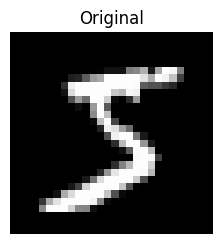

In [8]:
plt.figure(figsize=(12,6))

plt.subplot(2, 4, 1)

image=x_train[0]

plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.show()

In [9]:
normal_model = keras.Sequential([

    keras.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    keras.layers.MaxPooling2D(
        (2,2)
    ),

    keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    keras.layers.MaxPooling2D(
        (2,2)
    ),

    keras.layers.Flatten(),

    keras.layers.Dense(
        128,
        activation='relu'
    ),

    keras.layers.Dense(
        10,
        activation='softmax'
    ),
    
])

In [10]:
normal_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
normal_model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [12]:
history = normal_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.9581 - loss: 0.1390 - val_accuracy: 0.9823 - val_loss: 0.0576
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9851 - loss: 0.0451 - val_accuracy: 0.9878 - val_loss: 0.0463
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9907 - loss: 0.0285 - val_accuracy: 0.9912 - val_loss: 0.0312
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9928 - val_loss: 0.0312
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9947 - loss: 0.0162 - val_accuracy: 0.9893 - val_loss: 0.0338
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9957 - loss: 0.0130 - val_accuracy: 0.9900 - val_loss: 0.0460
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9967 - loss: 0.0104 - val_accuracy: 0.9910 - val_loss: 0.0381
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9975 -

In [13]:
l1model = keras.Sequential([

    keras.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    keras.layers.MaxPooling2D(
        (2,2)
    ),

    keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    keras.layers.MaxPooling2D(
        (2,2)
    ),

    keras.layers.Flatten(),

    keras.layers.Dense(
        128,
        activation='relu',
        kernel_regularizer = keras.regularizers.l1(0.0001)
    ),

    keras.layers.Dense(
        10,
        activation='softmax'
    ),
    
])

In [14]:
l1model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)


In [15]:
l1model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_l1 = l1model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9526 - loss: 0.3581 - val_accuracy: 0.9838 - val_loss: 0.1717
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9794 - loss: 0.1601 - val_accuracy: 0.9870 - val_loss: 0.1251
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9832 - loss: 0.1266 - val_accuracy: 0.9862 - val_loss: 0.1154
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9867 - loss: 0.1074 - val_accuracy: 0.9890 - val_loss: 0.1069
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9880 - loss: 0.0970 - val_accuracy: 0.9867 - val_loss: 0.1028
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9891 - loss: 0.0903 - val_accuracy: 0.9868 - val_loss: 0.0998
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9899 - loss: 0.0830 - val_accuracy: 0.9885 - val_loss: 0.0921
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9906 -

In [17]:
l2model = keras.Sequential([

    keras.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    keras.layers.MaxPooling2D(
        (2,2)
    ),

    keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    keras.layers.MaxPooling2D(
        (2,2)
    ),

    keras.layers.Flatten(),

    keras.layers.Dense(
        128,
        activation='relu',
        kernel_regularizer = keras.regularizers.l2(0.0001)
    ),

    keras.layers.Dense(
        10,
        activation='softmax'
    ),
    
])

In [18]:
l2model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [19]:
l2model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_l2 = l2model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9553 - loss: 0.1668 - val_accuracy: 0.9862 - val_loss: 0.0747
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9843 - loss: 0.0731 - val_accuracy: 0.9863 - val_loss: 0.0703
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9885 - loss: 0.0602 - val_accuracy: 0.9890 - val_loss: 0.0639
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9901 - loss: 0.0518 - val_accuracy: 0.9873 - val_loss: 0.0684
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9916 - loss: 0.0479 - val_accuracy: 0.9912 - val_loss: 0.0573
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9924 - loss: 0.0441 - val_accuracy: 0.9892 - val_loss: 0.0602
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9939 - loss: 0.0400 - val_accuracy: 0.9905 - val_loss: 0.0579
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9944 -